In [1]:
using LinearAlgebra
using BSplineKit
using PyCall
using DelimitedFiles
using Plots
using NonlinearEigenproblems
include("BaseFlow_cavity.jl")
include("Stability_Cavity.jl")

mode = 1:cavity; mode = 2:stationary; mode = 3:rotation;


Main.CRC_STA

In [3]:
Res = 1000
N_cheb = 129
mode = 1
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

([-2.3652355178959236e-21; 0.0022065891442621223; … ; -0.0007719927481758689; -3.6829751484828996e-19;;], [1.0; 0.9975417112810869; … ; 0.0006343015333476845; -1.6976977343855913e-19;;], [-1.908815819869238e-21; -1.0359793515841938e-5; … ; -3.6212129157292214e-6; -1.0773200297890632e-20;;])

In [ ]:
R = 275
be = 0.16
OMEGA = 8.0
omega = -0.102
c = 0.01
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= CRC_STA.assemble_mat(cof,D,D2,be,omega,R)     
L0,L1,L2 = CRC_STA.boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3,maxit = 500 , tol=1e-14)
vel = CRC_STA.eig_full(eigvec,N_cheb,1)
@show eigval

eigval = ComplexF64[0.0007899035561199346 + 0.0015766051153240977im, 0.052339998693087864 - 0.1408273652432606im, -0.036585441620056044 - 0.13720466842611537im]


3-element Vector{ComplexF64}:
 0.0007899035561199346 + 0.0015766051153240977im
  0.052339998693087864 - 0.1408273652432606im
 -0.036585441620056044 - 0.13720466842611537im

In [ ]:
TITLE = "Flow Field Visualization"
VARIABLES = "X", "Y", "Z", "U" ,"V" 
ZONE T="Step_01", I=1, J=121, K=29, F=POINT

In [33]:
open("total_DATA.dat", "w") do io
    for R = 85 : 5 : 500
        data = readdlm("R=$(R).dat")
        sorted_data = sortslices(data, dims=1, by=x->(x[1], x[2], x[3]))
        writedlm(io,sorted_data)
    end
end

In [50]:
R = 275
be = 0.0
alpha = 0.3
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
C = eigen(H0,H1)
val = C.values
vec = C.vectors
map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.5, val)
val_filter0 = val[map_index0]
vec_filter0 = vec[:,map_index0]
indictor = sum(real(val_filter0))/length(val_filter0)
map_index = map(x-> (real(x)) > indictor + 0.01 , val_filter0)
val_filter = val_filter0[map_index]
vec_filter = vec_filter0[:,map_index]
val_target = val_filter[findmax(imag.(val_filter))[2]]
vec_target = vec_filter[:,findmax(imag.(val_filter))[2]];
val_target

0.04270982766858854 - 0.001335422178005883im

In [51]:
indictor 
# imag.(val_target[1])

-0.00029175523306144334

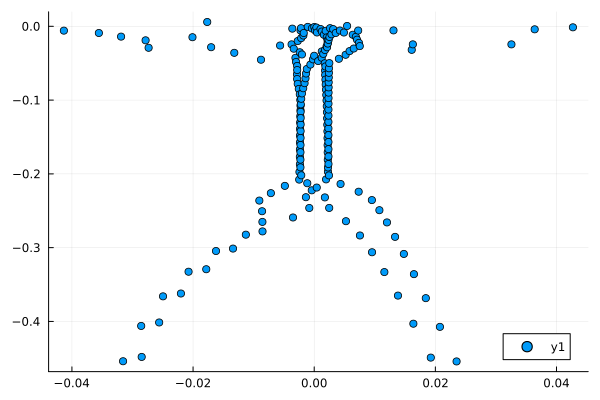

In [48]:
scatter(real(val_filter0),imag(val_filter0))

In [52]:
function EigenCore(cof,D,D2,be,alpha,R,N_cheb)
    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
    C = eigen(H0,H1)
    val = C.values
    vec = C.vectors
    map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.5, val)
    val_filter0 = val[map_index0]
    vec_filter0 = vec[:,map_index0]
    indictor = sum(real(val_filter0))/length(val_filter0)
    map_index = map(x-> (real(x)) > indictor + 0.01 , val_filter0)
    val_filter = val_filter0[map_index]
    vec_filter = vec_filter0[:,map_index]
    val_target = val_filter[findmax(imag.(val_filter))[2]]
    vec_target = vec_filter[:,findmax(imag.(val_filter))[2]];
    return val_target,vec_target
end

EigenCore (generic function with 1 method)

In [6]:
function interation(R_ini, R_end, alpha_ini, alpha_end, be_up, be_down, N_cheb)
    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(1000,-1,0.0,1)
    D,D2,z = CRC_BF.Cheb(N_cheb,1)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,1)
    open("test.dat", "w") do io
        for R = R_ini : 5 : R_end
            cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2, 1000)
            for alpha = alpha_ini  : 0.025 : alpha_end
                current_alpha_results = Matrix{Float64}[]
                val_root,vec_root = EigenCore(cof,D,D2,0.0,alpha,R,N_cheb)
                push!(current_alpha_results, [R alpha 0.0 real(val_root) imag(val_root)])
                val, vec = val_root, vec_root
                for be = 0.005 : 0.005 : be_up
                    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                    val,vec = rayleigh_quotient_iteration(H0,H1,val, vec)
                    push!(current_alpha_results, [R alpha be real(val) imag(val)])
                end
                val, vec = val_root, vec_root
                for be = -0.005 : -0.005 : be_down
                    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                    val,vec = rayleigh_quotient_iteration(H0,H1,val, vec)
                    push!(current_alpha_results, [R alpha be real(val) imag(val)])
                end
                sort!(current_alpha_results, by = row -> row[3])
                writedlm(io,current_alpha_results)
                flush(io)
            end
        end
    end
end

interation (generic function with 1 method)

In [ ]:
TITLE = "Flow Field Visualization"
VARIABLES = "X", "Y", "Z", "U" ,"V" 
ZONE T="Step_01", I=1, J=121, K=29, F=POINT

In [336]:
R_ini= 500
R_end = 500
be_up = 0.3
be_down = -0.3
alpha_ini = 0.001
alpha_end = 0.71
N_cheb = 129
interation(R_ini, R_end, alpha_ini, alpha_end, be_up, be_down, N_cheb)

正在计算雷诺数 R = 500 ...


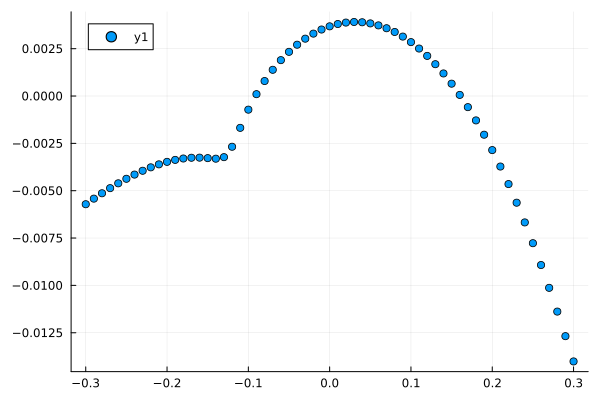

In [68]:
data = readdlm("test.dat")
Plots.scatter(data[:,3],data[:,5])

In [9]:
function rayleigh_quotient_iteration(A, B, sigma, q0=rand(size(A, 1), 1))

    flg = true
    i=1
    while flg
        i=i+1
        sigma0 = real(sigma[1]) + abs(imag(sigma[1]))im + 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end
        if i==20
            flg=false
        end
    end

      return sigma, q0
end

rayleigh_quotient_iteration (generic function with 2 methods)